### Filtering and Sorting the Salaries Dataset

In this section, we analyze the San Francisco Salaries dataset to find specific high earners based on the year and pay type.

**Objectives:**
1. **Highest Overtime Pay (2013):** We filter the dataset for records where the `Year` is 2013. Then, we sort these records in descending order based on `Overtime Pay` and select the top record to identify the employee who earned the most overtime.
2. **Top 5 Highest Base Pay (2011):** We filter the dataset for records where the `Year` is 2011. After that, we sort the data in descending order by `Base Pay` and extract the top 5 records to see the highest earners for that year.


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_excel("Course_Project_SanfranSicso_Salaries (1).xlsx")

# ---------------------------------------------------------
# Task 1: Find the employee with the highest Overtime Pay in 2013
# ---------------------------------------------------------
# Filter the data for the year 2013
df_2013 = df[df['Year'] == 2013]

# Sort by 'Overtime Pay' in descending order and get the first row (.iloc[0])
highest_overtime_2013 = df_2013.sort_values(by='Overtime Pay', ascending=False).iloc[0]

print("Highest Overtime Pay in 2013:")
print(f"Name: {highest_overtime_2013['Employee Name']}")
print(f"Overtime Pay: ${highest_overtime_2013['Overtime Pay']:,.2f}")
print("-" * 40)

# ---------------------------------------------------------
# Task 2: Find the top 5 employees with the highest Base Pay in 2011
# ---------------------------------------------------------
# Filter the data for the year 2011
df_2011 = df[df['Year'] == 2011]

# Sort by 'Base Pay' in descending order and get the top 5 rows (.head(5))
top_5_base_2011 = df_2011.sort_values(by='Base Pay', ascending=False).head(5)

print("Top 5 Highest Base Pay in 2011:")
# Display just the Employee Name and Base Pay columns for a cleaner output
print(top_5_base_2011[['Employee Name', 'Base Pay']].to_string(index=False))

Highest Overtime Pay in 2013:
Name: Gary Altenberg
Overtime Pay: $220,909.48
----------------------------------------
Top 5 Highest Base Pay in 2011:
     Employee Name  Base Pay
     John J Loftus 274126.50
     Naomi M Kelly 270641.50
  Barbara A Garcia 270591.04
    George  Gascon 252221.06
Kenneth A Lombardi 239247.00


### Calculating the Percentage of Other Pay

In this section, we create two new calculated fields:
1. **Total Pay:** The sum of `Base Pay`, `Overtime Pay`, and `Other Pay`.
2. **% Other Pay:** Calculated by dividing `Other Pay` by `Total Pay`.

**Objective:** Find out if any employees who earned a `Base Pay` of at least $100,000 in the year 2012 made more than 50% of their total salary from `Other Pay`.

In [ ]:
# 1. Create a calculated field for "Total Pay"
df['Total Pay'] = df['Base Pay'] + df['Overtime Pay'] + df['Other Pay']

# 2. Create the calculated field "% Other Pay"
df['% Other Pay'] = df['Other Pay'] / df['Total Pay']

# 3. Filter for employees in 2012 with Base Pay >= $100,000
df_2012_high_base = df[(df['Year'] == 2012) & (df['Base Pay'] >= 100000)]

# 4. Find if any of these employees earned more than 50% from Other Pay
high_other_pay_employees = df_2012_high_base[df_2012_high_base['% Other Pay'] > 0.50]

print("Employees in 2012 with >=$100k Base Pay earning >50% from Other Pay:\n")

if not high_other_pay_employees.empty:
    for index, row in high_other_pay_employees.iterrows():
        print(f"Name: {row['Employee Name']}")
        print(f"Base Pay: ${row['Base Pay']:,.2f}")
        print(f"Other Pay: ${row['Other Pay']:,.2f}")
        print(f"Total Pay: ${row['Total Pay']:,.2f}")
        print(f"% Other Pay: {row['% Other Pay']:.2%}")
else:
    print("No employees found matching these criteria.")

Employees in 2012 with >=$100k Base Pay earning >50% from Other Pay:

Name: Anna L Cuthbertson
Base Pay: $116,478.01
Other Pay: $124,034.01
Total Pay: $243,855.39
% Other Pay: 50.86%


### Grouping Job Titles into Categories (Curator)

In this step, we are categorizing employees based on their job titles.
1. **Categorization:** We create a new column called `Job Category`. We search for the word "Curator" (case-insensitive) in the `Job Title` column and assign any matches to the "Curator" category.
2. **Filtering for 2012-2013:** We filter the data to look only at employees in the "Curator" category during the years 2012 and 2013.
3. **Calculation:** We then count how many unique employees fall into this group and calculate their average `Base Pay` across those two years to find the highest earner.

In [ ]:
# 1. Create the "Job Category" column and assign "Curator" to relevant titles
# We use case=False to catch variations like "Curator" or "CURATOR"
df['Job Category'] = 'Other'
curator_mask = df['Job Title'].str.contains('Curator', case=False, na=False)
df.loc[curator_mask, 'Job Category'] = 'Curator'

# 2. Filter for Curator-related positions in 2012 or 2013
curators_12_13 = df[(df['Job Category'] == 'Curator') & (df['Year'].isin([2012, 2013]))]

# 3. Calculate how many unique employees held these positions
num_curator_employees = curators_12_13['Employee Name'].nunique()

# 4. Find the employee with the highest average Base Pay among this group
avg_base_pay_per_curator = curators_12_13.groupby('Employee Name')['Base Pay'].mean()
highest_earner_name = avg_base_pay_per_curator.idxmax()
highest_earner_pay = avg_base_pay_per_curator.max()

print(f"Number of employees in Curator-related positions (2012-2013): {num_curator_employees}")
print(f"Employee with the highest average Base Pay: {highest_earner_name}")
print(f"Average Base Pay: ${highest_earner_pay:,.2f}")

Number of employees in Curator-related positions (2012-2013): 9
Employee with the highest average Base Pay: Dennis G Sharp
Average Base Pay: $81,065.54


### San Francisco Salaries Analysis Dashboard

This dashboard provides a high-level overview of compensation across the city's various roles.

**Key Components:**
- **Top 5 Jobs by Total Pay:** A bar chart showing which job titles receive the highest aggregate compensation (Base + Overtime + Other Pay).
- **Top 5 Jobs by Overtime Pay:** A bar chart highlighting the roles where employees earn the most extra income through overtime hours.
- **Budget Breakdown:** A pie chart illustrating the percentage distribution of the total salary budget between Base Pay, Overtime, and Other Pay categories.

/tmp/ipykernel_2051/2287832396.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_total.values, y=top_5_total.index, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_2051/2287832396.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_overtime.values, y=top_5_overtime.index, ax=axes[0, 1], palette='magma')


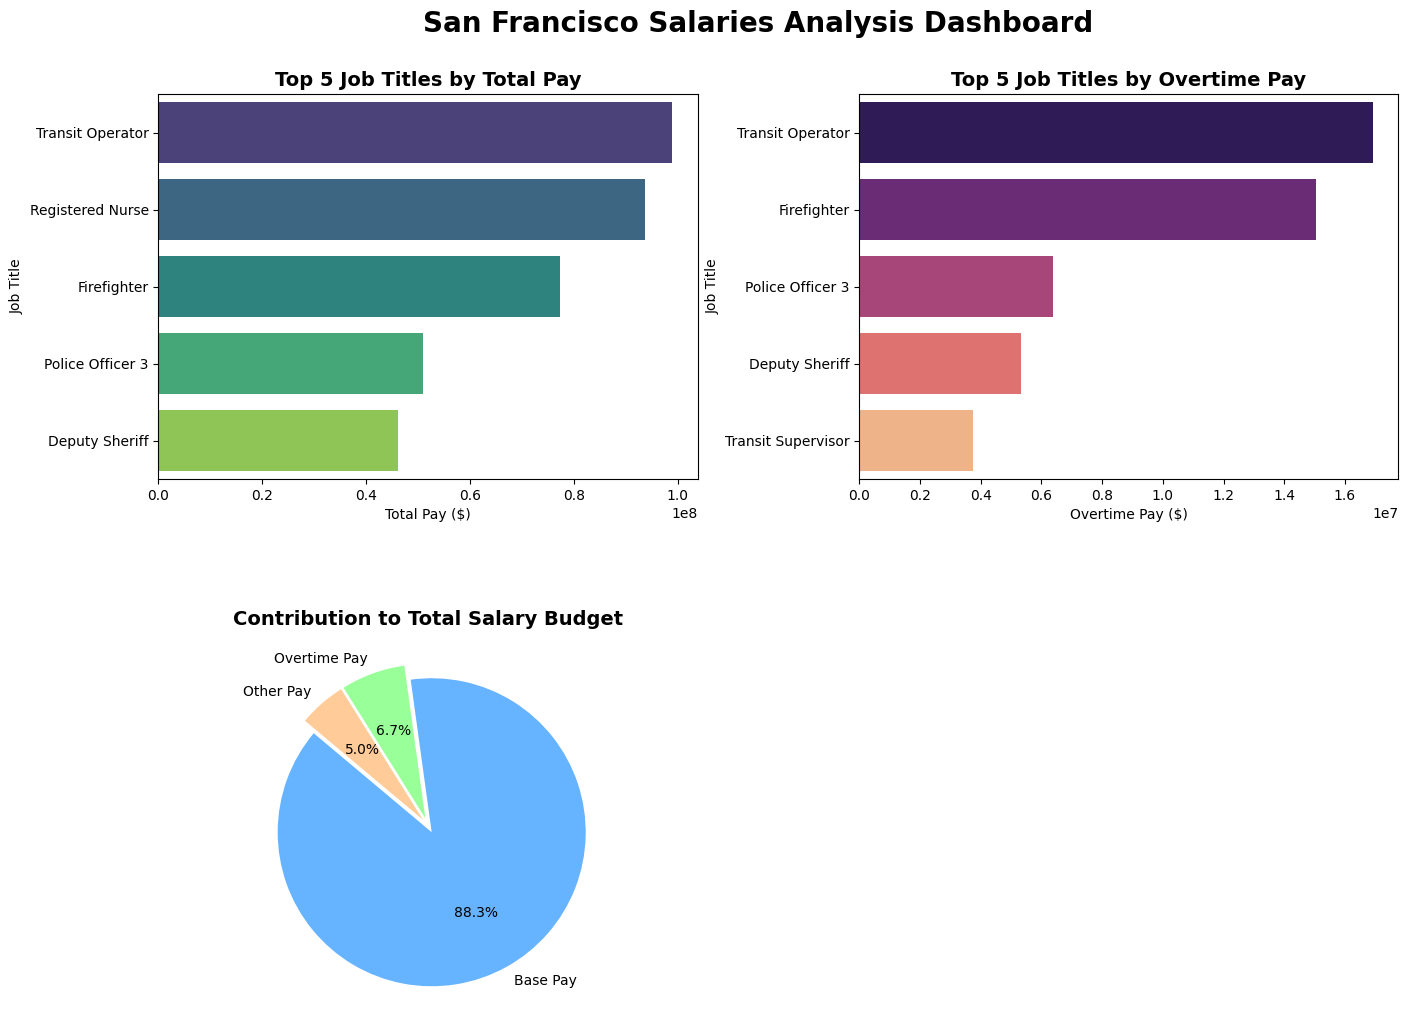

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded from previous steps.
# If not, uncomment the line below:
# df = pd.read_csv("Course_Project_SanfranSicso_Salaries (1).xlsx - San Francisco Salaries.csv")

# 1. Data Preparation
df['Total Pay'] = df['Base Pay'] + df['Overtime Pay'] + df['Other Pay']

# Grouping by Job Title to find top performers
top_5_total = df.groupby('Job Title')['Total Pay'].sum().sort_values(ascending=False).head(5)
top_5_overtime = df.groupby('Job Title')['Overtime Pay'].sum().sort_values(ascending=False).head(5)

# Calculating budget totals for the pie chart
budget_sums = df[['Base Pay', 'Overtime Pay', 'Other Pay']].sum()

# 2. Creating the Dashboard Layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Plot 1: Top 5 Job Categories by Total Pay ---
sns.barplot(x=top_5_total.values, y=top_5_total.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 5 Job Titles by Total Pay', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Pay ($)')
axes[0, 0].set_ylabel('Job Title')

# --- Plot 2: Top 5 Job Categories by Overtime Pay ---
sns.barplot(x=top_5_overtime.values, y=top_5_overtime.index, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Top 5 Job Titles by Overtime Pay', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Overtime Pay ($)')
axes[0, 1].set_ylabel('Job Title')

# --- Plot 3: Contribution to Total Salary Budget ---
axes[1, 0].pie(budget_sums, labels=budget_sums.index, autopct='%1.1f%%', startangle=140,
               colors=['#66b3ff','#99ff99','#ffcc99'], explode=(0.05, 0.05, 0.05))
axes[1, 0].set_title('Contribution to Total Salary Budget', fontsize=14, fontweight='bold')

# --- Remove the empty 4th subplot ---
fig.delaxes(axes[1, 1])

plt.suptitle('San Francisco Salaries Analysis Dashboard', fontsize=20, fontweight='bold', y=0.95)

# Display the dashboard
plt.show()